<h1>01. Generarea datelor experimentale</h1>

<p>Acest notebook construiește setul de date controlat folosit în lanțul experimental ECDSA → scurgere laterală → CNN → HNP.</p>

<p>Experimentul folosește curba secp256k1, 160 de semnături sintetice, 12 biți MSB considerați scurși pentru fiecare nonce și zgomot gaussian cu σ = 0,15 pentru setul profilat. Cheia privată și nonce-urile complete rămân în oracle și nu intră în datele publice furnizate etapelor de predicție.</p>

<h2>Scop și întrebare experimentală</h2>

<p>Întrebarea urmărită de proiect este dacă informație discretă despre nonce-ul ECDSA poate fi estimată din urme sintetice zgomotoase și apoi transformată într-o instanță HNP.</p>

<p>Pentru o semnătură ECDSA, cu cheia privată <i>d</i>, nonce <i>k</i>, hash-ul mesajului <i>z</i> și ordinea de grup <i>n</i>:</p>

\[
s \equiv k^{-1}(z+rd)\pmod n.
\]

<p>Dacă se cunosc primii <i>ℓ</i> biți ai lui <i>k</i>, putem scrie</p>

\[
k = a + \delta,\qquad
a=ar{k}\,2^{256-\ell},\qquad
0\le \delta < 2^{256-\ell}.
\]

<p>Notebook-ul nu atacă sisteme externe. Toate cheile, mesajele și nonce-urile sunt generate local, pentru reproducerea etapelor matematice și de machine learning.</p>

<h2>Configurația experimentului</h2>

<table>
<tr><th>Parametru</th><th>Valoare</th><th>Rol</th></tr>
<tr><td>Curba</td><td>secp256k1</td><td>grupul ECDSA simulat</td></tr>
<tr><td>Număr de eșantioane</td><td>160</td><td>semnături independente</td></tr>
<tr><td>Biți scurși</td><td>12</td><td>prefixul MSB folosit ulterior în HNP</td></tr>
<tr><td>Model de scurgere</td><td>HW</td><td>Hamming Weight pe prefixul procesat</td></tr>
<tr><td>Zgomot</td><td>σ = 0,15</td><td>setul profilat pentru CNN</td></tr>
<tr><td>Seed</td><td>20260919</td><td>reproductibilitate</td></tr>
</table>

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "informatica").is_dir() and (p / "notebooks").is_dir()
)

ECDSA_DIR = PROJECT_ROOT / "informatica" / "ECDSA"
CNN_DIR = PROJECT_ROOT / "informatica" / "cnn"
DATASET_DIR = PROJECT_ROOT / "informatica" / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "informatica" / "artifacts"
RESULTS_DIR = PROJECT_ROOT / "results"

for path in (ECDSA_DIR, CNN_DIR, DATASET_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from generate import generate
from dataset_generator3 import CURVE, load_public_dataset, load_ground_truth, is_on_curve, scalar_mult, INF
from ecdsa_leakage_model4 import generate_clean_leakage, integer_to_bits

<h2>Generarea setului</h2>

<p>Funcția proiectului scrie separat patru artefacte: date publice, oracle, date pentru profilarea CNN și împărțirea train/validation/test. Seed-ul este fixat pentru ca aceeași rulare să poată fi refăcută.</p>

In [ ]:
metadata = generate(
    sample_count=160,
    leaked_bits=12,
    noise_sigma=0.15,
    seed=20260919,
    leakage_mode="HW",
    train_fraction=0.70,
    validation_fraction=0.15,
)

display(pd.DataFrame([metadata]).T.rename(columns={0: "valoare"}))

,valoare
format_version,2
curve,secp256k1
sample_count,160
leaked_bits,12
trace_length,256
noise_sigma,0.15
leakage_model,HW
seed,20260919
synthetic,True
public_file,public_dataset.json


<h2>Verificarea curbei și a semnăturilor</h2>

<p>Înainte de analiza statistică verificăm generatorul <i>G</i>, ordinul subgrupului și coerența dintre semnătura publică și nonce-ul din oracle. Aceste verificări sunt proprietăți interne ale simulării.</p>

In [ ]:
public_records = load_public_dataset()
oracle = load_ground_truth()

curve_ok = is_on_curve(CURVE, CURVE.G)
order_ok = scalar_mult(CURVE, CURVE.n, CURVE.G) == INF

truth_by_id = {int(k): v for k, v in oracle["samples"].items()}
leakage_ok = True
sample_ok = len(public_records) == len(truth_by_id) == 160

for record in public_records:
    sample_id = int(record["sample_id"])
    truth = truth_by_id[sample_id]
    nonce = int(truth["nonce_k"])
    leaked = int(record["leaked_bits"])
    hidden_bits = CURVE.n.bit_length() - leaked
    expected_prefix = int(truth["leaked_nonce_prefix"])
    leakage_ok &= (nonce >> hidden_bits) == expected_prefix

checks = pd.DataFrame([
    ["Generatorul este pe curbă", curve_ok],
    ["nG este punctul la infinit", order_ok],
    ["160 eșantioane publice și oracle", sample_ok],
    ["Prefixele MSB sunt coerente cu nonce-urile", leakage_ok],
], columns=["verificare", "rezultat"])

display(checks)
assert checks["rezultat"].all()

,verificare,rezultat
0,Generatorul este pe curbă,True
1,nG este punctul la infinit,True
2,160 eșantioane publice și oracle,True
3,Prefixele MSB sunt coerente cu nonce-urile,True


<h2>Structura datelor publice</h2>

<p>Datele publice conțin exact informația disponibilă unei etape de atac: mesajul, hash-ul <i>z</i>, componentele semnăturii <i>r</i> și <i>s</i> și numărul de biți considerați disponibili.</p>

In [ ]:
public_df = pd.DataFrame(public_records)
public_df["z_hex"] = public_df["z"].map(lambda x: f"{int(x):064x}")
public_df["r_hex"] = public_df["r"].map(lambda x: f"{int(x):064x}")
public_df["s_hex"] = public_df["s"].map(lambda x: f"{int(x):064x}")

display(public_df[["sample_id", "message", "leaked_bits", "z_hex", "r_hex", "s_hex"]].head(6))
display(public_df[["z", "r", "s", "leaked_bits"]].describe().T)

,sample_id,message,leaked_bits,z_hex,r_hex,s_hex
0,0,HNP benchmark message 0 / token=47bc09578f758ef6,12,6ab7f9d4285ec6e5abeebd91ac5d1f154b1750217c61be...,e49170aba274cd12ec82e6de70c90e90f56ddd7b1156f3...,e134f3825a43ddc17623d6a9906a0b81aff617a8de96a7...
1,1,HNP benchmark message 1 / token=88e0c22e3b219d77,12,fed8aae1c0f843df5ba2e80782360d2b7e5eee56f1696c...,f4d71045a1c47021a094245916e7c4f085d24549ee599a...,d39f69350dbc9dda86f6b85ec5f3cedfbb964e6f4b0e78...
2,2,HNP benchmark message 2 / token=caf09f7319638db0,12,614ef1a59f68cf694c82d202c2a086adb97cef7fd95fa5...,7ed5ccc66e8c05dffbc5ae36ac54ac4e04cb403808d3f1...,edfaa4729ca6ea86df41e67efa6d8c3e3aa23f6040eefb...
3,3,HNP benchmark message 3 / token=1a09ba15397db5f7,12,f3e09bf42838c14fb4c433f756d3572c894033dea64187...,6765da4477f82204e8b7584ec632a9909cd9cf60bd5bba...,5cc11373f04bb3e414489a04da56853ff321b33d063427...
4,4,HNP benchmark message 4 / token=10512f20fa2add11,12,a89ad15314be5a04de744c42befb58e4642a6232e04247...,b24d8cd532836a29fcd1798d2babd8c75e0e0edb264e79...,55a7fbaa69dc8287fa5f2dd67eeab1f1f301b5ca9154e7...
5,5,HNP benchmark message 5 / token=b14445664ecb9472,12,5544f6b39a285f551ae7cdc6fd23f8f908bcab9fec1932...,dde426dc36f3e1be352c3fc48f49121ec67d50d7b80780...,ca48b74d99e88039dfdf7aaadeadd982ed8c634d197cf6...


,count,mean,std,min,25%,50%,75%,max
leaked_bits,160.0,12.0,0.0,12.0,12.0,12.0,12.0,12.0


<h2>Separarea oracle-ului</h2>

<p>Cheia privată și nonce-urile complete sunt date de control pentru evaluarea simulării. CNN-ul și baseline-ul nu trebuie să citească aceste valori pentru a produce predicții; oracle-ul este folosit numai la generarea urmelor sintetice și la evaluarea rezultatului.</p>

In [ ]:
profile_records = json.loads((ARTIFACTS_DIR / "profile_dataset.json").read_text(encoding="utf-8"))

separation = pd.DataFrame([
    ["public_dataset.json", len(public_records), "z, r, s, leaked_bits", "fără cheia privată și fără nonce complet"],
    ["oracle_dataset.json", len(truth_by_id), "cheie privată, nonce, prefix real", "control experimental"],
    ["profile_dataset.json", len(profile_records), "trace, bit_labels, z, r, s", "input pentru model"],
], columns=["fișier", "eșantioane", "câmpuri", "utilizare"])

display(separation)

,fișier,eșantioane,câmpuri,utilizare
0,public_dataset.json,160,"z, r, s, leaked_bits",fără cheia privată și fără nonce complet
1,oracle_dataset.json,160,"cheie privată, nonce, prefix real",control experimental
2,profile_dataset.json,160,"trace, bit_labels, z, r, s",input pentru model


<h2>O urmă sintetică</h2>

<p>Modelul HW calculează greutatea Hamming a prefixului de nonce procesat la fiecare poziție. Pentru fiecare poziție adăugăm zgomot gaussian independent.</p>

\[
HW(v)=\operatorname{popcount}(v),
\qquad
y_j = HW(k_{\le j})+
arepsilon_j,
\qquad

arepsilon_j\sim\mathcal N(0,\sigma^2).
\]

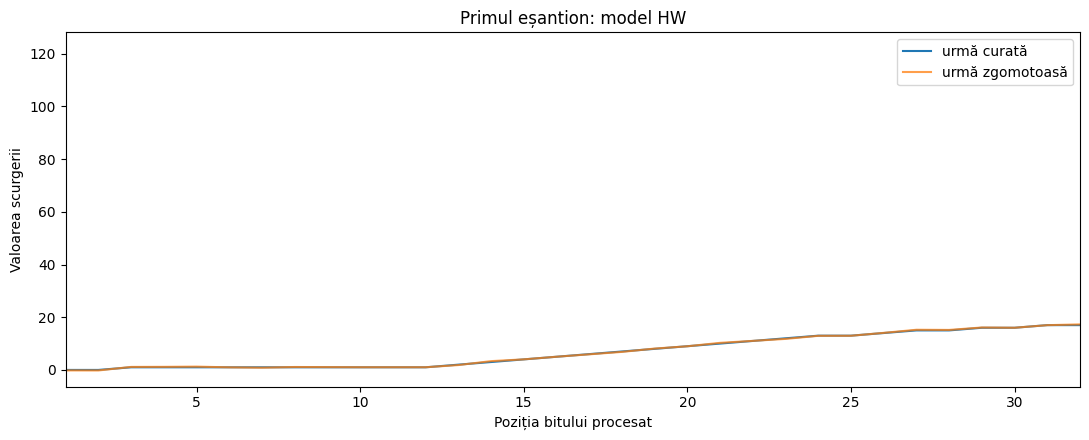

In [ ]:
first_id = 0
first_truth = truth_by_id[first_id]
first_nonce = int(first_truth["nonce_k"])

clean = generate_clean_leakage(first_nonce, CURVE.n.bit_length(), mode="HW", alpha=1.0)
noisy = profile_records[first_id]["trace"]

fig = plt.figure(figsize=(11, 4.5))
x = np.arange(1, len(clean) + 1)
plt.plot(x, clean, label="urmă curată")
plt.plot(x, noisy, label="urmă zgomotoasă", alpha=0.75)
plt.xlim(1, 32)
plt.xlabel("Poziția bitului procesat")
plt.ylabel("Valoarea scurgerii")
plt.title("Primul eșantion: model HW")
plt.legend()
plt.tight_layout()
plt.show()

<h2>Verificarea etichetelor pentru CNN</h2>

<p>Etichetele din setul profilat trebuie să reprezinte exact biții nonce-ului, în ordine MSB → LSB. Pentru experimentul curent, CNN-ul va consuma primele 12 poziții, adică prefixul utilizat de etapa HNP.</p>

In [ ]:
label_checks = []
for record in profile_records:
    sample_id = int(record["sample_id"])
    nonce = int(truth_by_id[sample_id]["nonce_k"])
    expected = integer_to_bits(nonce, CURVE.n.bit_length())[:12]
    observed = list(map(int, record["bit_labels"][:12]))
    label_checks.append(expected == observed)

label_accuracy = float(np.mean(label_checks))
print(f"Concordanța etichetelor de 12 biți: {100 * label_accuracy:.2f}%")
assert label_accuracy == 1.0

Concordanța etichetelor de 12 biți: 100.00%


<h2>Artefacte produse</h2>

<p>Rularea creează setul reproducibil pentru celelalte notebook-uri. Fișierul oracle trebuie tratat ca material de test și nu ca intrare publică pentru model.</p>

In [ ]:
generated_files = [
    "public_dataset.json",
    "oracle_dataset.json",
    "profile_dataset.json",
    "dataset_metadata.json",
    "dataset_split.json",
]

display(pd.DataFrame({
    "fișier": generated_files,
    "existent": [ (ARTIFACTS_DIR / name).exists() for name in generated_files ],
    "dimensiune_bytes": [ (ARTIFACTS_DIR / name).stat().st_size if (ARTIFACTS_DIR / name).exists() else 0 for name in generated_files ],
}))

,fișier,existent,dimensiune_bytes
0,public_dataset.json,True,61564
1,oracle_dataset.json,True,23985
2,profile_dataset.json,True,1117810
3,dataset_metadata.json,True,365
4,dataset_split.json,True,1387


<h2>Referințe</h2>

<p>T. Pornin, RFC 6979, definiția parametrilor ECDSA și discuția despre generarea nonce-ului: https://www.rfc-editor.org/rfc/rfc6979</p>

<p>Bitcoin Core, parametrii secp256k1: https://github.com/bitcoin-core/secp256k1/blob/master/sage/secp256k1_params.sage</p>

<p>În repository, implementarea folosită aici se află în <code>informatica/ECDSA/dataset_generator3.py</code> și <code>informatica/dataset/generate.py</code>.</p>